Total valid patients found: 281
Indexing 3D volumes for Training...
Indexing 3D volumes for Testing...


2026-03-25 14:20:56.201124: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Starting 3D-UNet Training...
Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 638s 6s/step - accuracy: 0.7976 - auc: 0.9696 - loss: 0.5696 - val_accuracy: 0.9386 - val_auc: 1.0000 - val_loss: 0.3519
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 489s 4s/step - accuracy: 0.9290 - auc: 1.0000 - loss: 0.3546 - val_accuracy: 0.9912 - val_auc: 1.0000 - val_loss: 0.2215
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 497s 4s/step - accuracy: 0.9888 - auc: 1.0000 - loss: 0.1417 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.0051
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 567s 5s/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.0051 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 7.5116e-04
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 499s 4s/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.0016 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 2.8519e-04
Epoch 6/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 495s 4s/step - accuracy: 1.0000 - auc: 1.0000 - loss: 7.0014e-04 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss:

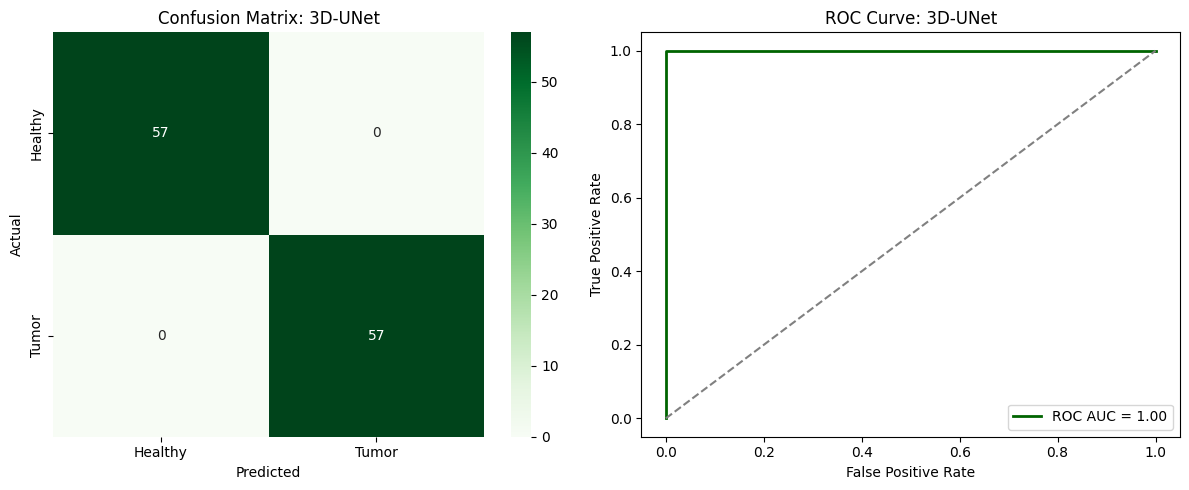


Classification Report:
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00        57
       Tumor       1.00      1.00      1.00        57

    accuracy                           1.00       114
   macro avg       1.00      1.00      1.00       114
weighted avg       1.00      1.00      1.00       114

Final AUC Score: 1.0000


In [2]:
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.utils import Sequence
from tensorflow.keras.layers import Input, Conv3D, MaxPooling3D, Conv3DTranspose, concatenate, GlobalAveragePooling3D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# --- 1. CONFIGURATION ---
PATCH_SIZE = 64  # 3D Cubes of 64x64x64
BATCH_SIZE = 4   # 3D models are memory intensive; keep this small
BASE_PATH = "/kaggle/input/datasets/rksrank1/pancreatic-cancer/Task07_Pancreas"
IMAGE_DIR = os.path.join(BASE_PATH, "imagesTr")
MASK_DIR = os.path.join(BASE_PATH, "labelsTr")

# --- 2. DATA SEQUENCE (Fixed for Hidden Files & Balanced Resampling) ---
class Pancreas3DSequence(Sequence):
    def __init__(self, patient_files, batch_size=BATCH_SIZE, is_training=True):
        self.patient_files = patient_files
        self.batch_size = batch_size
        self.is_training = is_training
        self.samples = self._prepare_balanced_patches()

    def _prepare_balanced_patches(self):
        """
        Resampling Technique: 
        Ensures a 1:1 ratio of Tumor vs Healthy patches.
        Extracts 3D cubes centered on tumor labels.
        """
        all_samples = []
        print(f"Indexing 3D volumes for {'Training' if self.is_training else 'Testing'}...")
        
        for file in self.patient_files:
            # FIX: Ensure we ignore Mac metadata '._' files
            if file.startswith("._"):
                continue
                
            mask_path = os.path.join(MASK_DIR, file)
            if not os.path.exists(mask_path):
                continue

            mask_vol = nib.load(mask_path).get_fdata()
            tumor_indices = np.argwhere(mask_vol == 2) # Class 2 = Tumor
            
            if len(tumor_indices) > 0:
                # 1. Tumor Patch (Minority Class)
                center = tumor_indices[len(tumor_indices)//2]
                all_samples.append((file, center, 1))
                
                # 2. Healthy Patch (Majority Class Undersampling)
                # Take a random healthy corner of the same volume
                all_samples.append((file, [10, 10, 10], 0))
        
        np.random.shuffle(all_samples)
        return all_samples

    def __len__(self):
        return int(np.ceil(len(self.samples) / self.batch_size))

    def __getitem__(self, idx):
        batch = self.samples[idx * self.batch_size : (idx + 1) * self.batch_size]
        X, y = [], []
        
        for file, center, label in batch:
            img_vol = nib.load(os.path.join(IMAGE_DIR, file)).get_fdata()
            z, y_c, x = [int(c) for c in center]
            
            # Extract 3D Cube with safe boundaries
            z_s, y_s, x_s = max(0, z-32), max(0, y_c-32), max(0, x-32)
            patch = img_vol[z_s:z_s+64, y_s:y_s+64, x_s:x_s+64]
            
            # Zero-padding if volume is smaller than 64x64x64
            if patch.shape != (64, 64, 64):
                patch = np.pad(patch, [(0, 64-s) for s in patch.shape], mode='constant')
            
            # Preprocessing: Medical Windowing
            patch = np.clip(patch, -100, 200)
            patch = (patch + 100) / 300.0
            
            X.append(patch[..., np.newaxis])
            y.append(label)
            
        return np.array(X), np.array(y)

# --- 3. BUILD 3D-UNet CLASSIFIER ---
def build_3d_unet():
    inputs = Input((PATCH_SIZE, PATCH_SIZE, PATCH_SIZE, 1))
    
    # Encoder (Downsampling)
    c1 = Conv3D(32, 3, activation='relu', padding='same')(inputs)
    p1 = MaxPooling3D(2)(c1)
    
    c2 = Conv3D(64, 3, activation='relu', padding='same')(p1)
    p2 = MaxPooling3D(2)(c2)
    
    # Bridge
    b = Conv3D(128, 3, activation='relu', padding='same')(p2)
    
    # Decoder (Upsampling & Skip Connections)
    u1 = Conv3DTranspose(64, 2, strides=2, padding='same')(b)
    u1 = concatenate([u1, c2])
    
    # Classification logic
    gap = GlobalAveragePooling3D()(u1)
    dense = Dense(128, activation='relu')(gap)
    drop = Dropout(0.4)(dense)
    output = Dense(1, activation='sigmoid')(drop)
    
    model = Model(inputs, output)
    model.compile(optimizer=Adam(1e-4), loss='binary_crossentropy', 
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return model

# --- 4. EXECUTION ---
# UPDATED FILE LOADING: Filters Mac metadata and system files
all_files = sorted([
    f for f in os.listdir(IMAGE_DIR) 
    if (f.endswith(".nii") or f.endswith(".nii.gz")) 
    and not f.startswith(".")
])

print(f"Total valid patients found: {len(all_files)}")

if len(all_files) == 0:
    print("No files found. Please check your path.")
else:
    train_f, test_f = train_test_split(all_files, test_size=0.2, random_state=42)

    train_seq = Pancreas3DSequence(train_f)
    test_seq = Pancreas3DSequence(test_f, is_training=False)

    model_3d = build_3d_unet()
    print("\nStarting 3D-UNet Training...")
    model_3d.fit(train_seq, validation_data=test_seq, epochs=5)

    # --- 5. FINAL EVALUATION (Confusion Matrix & ROC) ---
    print("\nEvaluating 3D-UNet...")
    y_true, y_probs = [], []
    for i in range(len(test_seq)):
        xb, yb = test_seq[i]
        preds = model_3d.predict(xb, verbose=0)
        y_true.extend(yb)
        y_probs.extend(preds.flatten())

    y_true = np.array(y_true)
    y_probs = np.array(y_probs)
    y_pred = (y_probs > 0.5).astype(int)

    # Metrics
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)

    # Plot Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Healthy', 'Tumor'], yticklabels=['Healthy', 'Tumor'])
    plt.title('Confusion Matrix: 3D-UNet')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')

    # Plot ROC Curve
    plt.subplot(1, 2, 2)
    plt.plot(fpr, tpr, color='darkgreen', lw=2, label=f'ROC AUC = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.title('ROC Curve: 3D-UNet')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['Healthy', 'Tumor']))
    print(f"Final AUC Score: {roc_auc:.4f}")

2026-03-25 18:27:57.752285: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774463278.091063      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774463278.197389      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774463279.033511      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774463279.033559      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774463279.033562      55 computation_placer.cc:177] computation placer alr

Total valid patients found: 281
Indexing 3D volumes for Training...
Indexing 3D volumes for Testing...


I0000 00:00:1774463412.110473      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0



Starting 3D-UNet Training...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5


I0000 00:00:1774463429.005502     105 service.cc:152] XLA service 0x7bd19804e3a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774463429.005542     105 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1774463429.604844     105 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/112 ━━━━━━━━━━━━━━━━━━━━ 20:13 11s/step - accuracy: 0.5000 - auc: 0.0000e+00 - loss: 0.7081

I0000 00:00:1774463434.520208     105 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


112/112 ━━━━━━━━━━━━━━━━━━━━ 352s 3s/step - accuracy: 0.5037 - auc: 0.6983 - loss: 0.6674 - val_accuracy: 0.6491 - val_auc: 0.9038 - val_loss: 0.6015
Epoch 2/5
112/112 ━━━━━━━━━━━━━━━━━━━━ 52s 462ms/step - accuracy: 0.7524 - auc: 0.8906 - loss: 0.5292 - val_accuracy: 0.8860 - val_auc: 0.9167 - val_loss: 0.3163
Epoch 3/5
112/112 ━━━━━━━━━━━━━━━━━━━━ 50s 451ms/step - accuracy: 0.8858 - auc: 0.9087 - loss: 0.3085 - val_accuracy: 0.8947 - val_auc: 0.9295 - val_loss: 0.2956
Epoch 4/5
112/112 ━━━━━━━━━━━━━━━━━━━━ 43s 381ms/step - accuracy: 0.8460 - auc: 0.9110 - loss: 0.3269 - val_accuracy: 0.8860 - val_auc: 0.9351 - val_loss: 0.2869
Epoch 5/5
112/112 ━━━━━━━━━━━━━━━━━━━━ 51s 458ms/step - accuracy: 0.8829 - auc: 0.9327 - loss: 0.2787 - val_accuracy: 0.8860 - val_auc: 0.9418 - val_loss: 0.2811

Evaluating 3D-UNet...


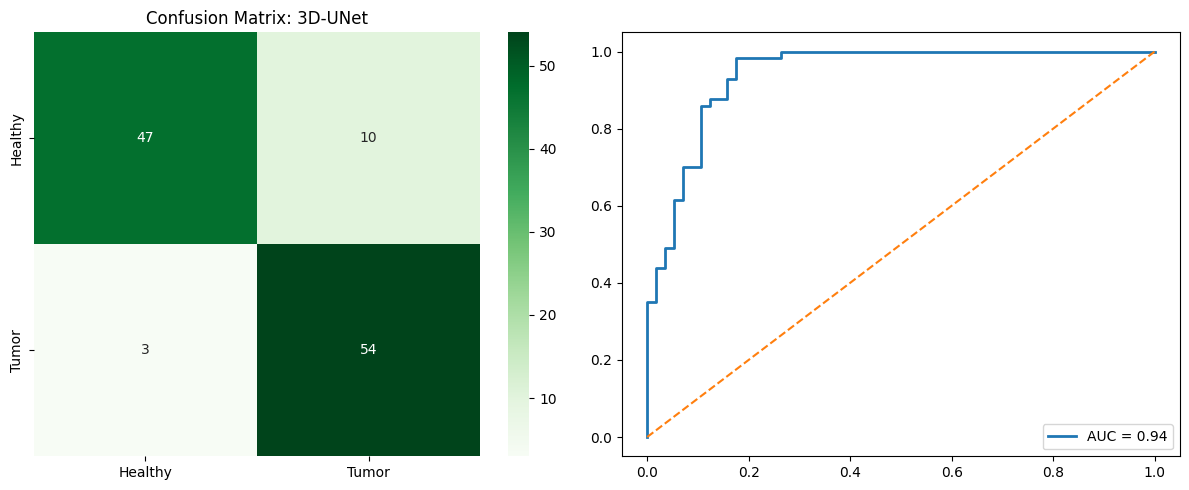

              precision    recall  f1-score   support

           0       0.94      0.82      0.88        57
           1       0.84      0.95      0.89        57

    accuracy                           0.89       114
   macro avg       0.89      0.89      0.89       114
weighted avg       0.89      0.89      0.89       114

AUC: 0.9431


In [1]:
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.utils import Sequence
from tensorflow.keras.layers import Input, Conv3D, MaxPooling3D, Conv3DTranspose, concatenate, GlobalAveragePooling3D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# --- 1. CONFIGURATION ---
PATCH_SIZE = 64
BATCH_SIZE = 4
BASE_PATH = "/kaggle/input/datasets/rksrank1/pancreatic-cancer/Task07_Pancreas"
IMAGE_DIR = os.path.join(BASE_PATH, "imagesTr")
MASK_DIR = os.path.join(BASE_PATH, "labelsTr")

# --- 2. DATA SEQUENCE (FIXED) ---
class Pancreas3DSequence(Sequence):
    def __init__(self, patient_files, batch_size=BATCH_SIZE, is_training=True):
        self.patient_files = patient_files
        self.batch_size = batch_size
        self.is_training = is_training
        self.samples = self._prepare_balanced_patches()

    def _prepare_balanced_patches(self):
        all_samples = []
        print(f"Indexing 3D volumes for {'Training' if self.is_training else 'Testing'}...")
        
        for file in self.patient_files:
            if file.startswith("._"):
                continue
                
            mask_path = os.path.join(MASK_DIR, file)
            if not os.path.exists(mask_path):
                continue

            mask_vol = nib.load(mask_path).get_fdata()
            tumor_indices = np.argwhere(mask_vol == 2)

            if len(tumor_indices) > 0:
                # ✅ RANDOM tumor point
                rand_idx = np.random.randint(len(tumor_indices))
                tumor_center = tumor_indices[rand_idx]
                all_samples.append((file, tumor_center, 1))
                
                # ✅ RANDOM healthy point (NOT fixed)
                h, w, d = mask_vol.shape
                while True:
                    rand_point = [
                        np.random.randint(0, h),
                        np.random.randint(0, w),
                        np.random.randint(0, d)
                    ]
                    if mask_vol[tuple(rand_point)] == 0:
                        break
                all_samples.append((file, rand_point, 0))
        
        np.random.shuffle(all_samples)
        return all_samples

    def __len__(self):
        return int(np.ceil(len(self.samples) / self.batch_size))

    def __getitem__(self, idx):
        batch = self.samples[idx * self.batch_size : (idx + 1) * self.batch_size]
        X, y = [], []
        
        for file, center, label in batch:
            img_vol = nib.load(os.path.join(IMAGE_DIR, file)).get_fdata()
            z, y_c, x = [int(c) for c in center]
            
            z_s, y_s, x_s = max(0, z-32), max(0, y_c-32), max(0, x-32)
            patch = img_vol[z_s:z_s+64, y_s:y_s+64, x_s:x_s+64]
            
            if patch.shape != (64, 64, 64):
                patch = np.pad(patch, [(0, 64-s) for s in patch.shape], mode='constant')
            
            patch = np.clip(patch, -100, 200)
            patch = (patch + 100) / 300.0
            
            X.append(patch[..., np.newaxis])
            y.append(label)
            
        return np.array(X), np.array(y)

# --- 3. MODEL ---
def build_3d_unet():
    inputs = Input((PATCH_SIZE, PATCH_SIZE, PATCH_SIZE, 1))
    
    c1 = Conv3D(32, 3, activation='relu', padding='same')(inputs)
    p1 = MaxPooling3D(2)(c1)
    
    c2 = Conv3D(64, 3, activation='relu', padding='same')(p1)
    p2 = MaxPooling3D(2)(c2)
    
    b = Conv3D(128, 3, activation='relu', padding='same')(p2)
    
    u1 = Conv3DTranspose(64, 2, strides=2, padding='same')(b)
    u1 = concatenate([u1, c2])
    
    gap = GlobalAveragePooling3D()(u1)
    dense = Dense(128, activation='relu')(gap)
    drop = Dropout(0.4)(dense)
    output = Dense(1, activation='sigmoid')(drop)
    
    model = Model(inputs, output)
    model.compile(optimizer=Adam(1e-4), loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return model

# --- 4. EXECUTION ---
all_files = sorted([
    f for f in os.listdir(IMAGE_DIR)
    if (f.endswith(".nii") or f.endswith(".nii.gz"))
    and not f.startswith(".")
])

print(f"Total valid patients found: {len(all_files)}")

train_f, test_f = train_test_split(all_files, test_size=0.2, random_state=42)

train_seq = Pancreas3DSequence(train_f)
test_seq = Pancreas3DSequence(test_f, is_training=False)

model_3d = build_3d_unet()

print("\nStarting 3D-UNet Training...")
model_3d.fit(train_seq, validation_data=test_seq, epochs=5)

# --- 5. EVALUATION ---
print("\nEvaluating 3D-UNet...")
y_true, y_probs = [], []

for i in range(len(test_seq)):
    xb, yb = test_seq[i]
    preds = model_3d.predict(xb, verbose=0)
    y_true.extend(yb)
    y_probs.extend(preds.flatten())

y_true = np.array(y_true)
y_probs = np.array(y_probs)
y_pred = (y_probs > 0.5).astype(int)

fpr, tpr, _ = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Healthy', 'Tumor'],
            yticklabels=['Healthy', 'Tumor'])
plt.title('Confusion Matrix: 3D-UNet')

plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.legend()

plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred))
print(f"AUC: {roc_auc:.4f}")